In [178]:
from pathlib import Path

PROJECT_ROOT = Path.cwd().parents[1]
print(PROJECT_ROOT)

/Users/florianb/Downloads/ai-customer-insights-engine


In [ ]:
import json
from IPython.display import display, HTML

import pandas as pd
import numpy as np
from openai import AsyncOpenAI
from ragas.llms import llm_factory
from ragas.metrics.collections import (
    ContextRelevance,
)

from src.rag import retriever as retriever_module
from src.rag import rag_chain as rag_chain_module

from config import config

In [181]:
import importlib

importlib.reload(config)
importlib.reload(retriever_module)
importlib.reload(rag_chain_module)

<module 'src.rag.rag_chain' from '/Users/florianb/Downloads/ai-customer-insights-engine/src/rag/rag_chain.py'>

In [ ]:
print(f"HUGGINGFACE_EMBEDDING_MODEL = {config.HUGGINGFACE_EMBEDDING_MODEL}")

HUGGINGFACE_EMBEDDING_MODEL = sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
LLM_MODEL = gpt-4o-mini
MAX_COMPLETION_TOKENS = 300


In [257]:
evaluation_path = PROJECT_ROOT / "data/evaluation/evaluation_questions.json"

with open(evaluation_path, "r", encoding="utf-8") as f:
    questions = json.load(f)

In [258]:
questions = questions[:10]

In [259]:
questions

['Quels types de problèmes rencontrent les clients avec le service client ?',
 "Comment les clients décrivent-ils leur expérience lors de l'ouverture d'un compte ?",
 'Quelles difficultés les utilisateurs rencontrent-ils lors de la validation de leurs opérations ?',
 'Quels reproches sont faits concernant la réactivité du service client ?',
 'Comment les clients se sentent-ils face à des blocages de compte sans explication ?',
 'Quelles plaintes sont formulées concernant les frais bancaires ?',
 'Comment les clients perçoivent-ils la qualité des réponses fournies par le service client ?',
 'Quels problèmes sont signalés concernant la réception de cartes bancaires ?',
 'Comment les clients décrivent-ils leur expérience avec les délais de traitement des demandes ?',
 'Quelles frustrations sont exprimées concernant les communications par e-mail ?']

In [260]:
# Retriever seul
retriever_only = retriever_module.create_retriever(
    model_name=config.HUGGINGFACE_EMBEDDING_MODEL,
    use_reranker=False,
    retriever_k=5,
)

# Retriever + reranker
retriever_reranker = retriever_module.create_retriever(
    model_name=config.HUGGINGFACE_EMBEDDING_MODEL,
    use_reranker=True,
    retriever_k=20,
    reranker_top_n=5,
)

In [261]:
client = AsyncOpenAI(
    api_key=config.OPENAI_API_KEY
)

evaluation_llm = llm_factory(
    client=client,
    model="gpt-4o-mini",
)

scorer = ContextRelevance(
    llm=evaluation_llm
)

In [262]:
results_retriever_only = []

for i, question in enumerate(questions, start=1):

    docs = await retriever_only.ainvoke(question)

    retrieved_contexts = [
        doc.page_content
        for doc in docs
    ]

    result = await scorer.ascore(
        user_input=question,
        retrieved_contexts=retrieved_contexts,
    )

    results_retriever_only.append({
        "question_id": i,
        "question": question,
        "retrieved_contexts": retrieved_contexts,
        "context_relevance": result.value,
    })

In [263]:
results_retriever_reranker = []

for i, question in enumerate(questions, start=1):

    docs = await retriever_reranker.ainvoke(question)

    retrieved_contexts = [
        doc.page_content
        for doc in docs
    ]

    result = await scorer.ascore(
        user_input=question,
        retrieved_contexts=retrieved_contexts,
    )

    results_retriever_reranker.append({
        "question_id": i,
        "question": question,
        "retrieved_contexts": retrieved_contexts,
        "context_relevance": result.value,
    })

In [172]:
pd.set_option("display.max_colwidth", None)

In [274]:
comparison = []

for i in range(len(questions)):
    comparison.append({
        "n°": i+1,
        "Question": questions[i],
        "Contexts Retriever seul": "<br><br>".join(
            results_retriever_only[i]['retrieved_contexts']
        ),
        "Score Retriever seul": f"{results_retriever_only[i]['context_relevance']:.2f}",
        "Contexts Retriever + Reranker": "<br><br>".join(
            results_retriever_reranker[i]["retrieved_contexts"]
        ),
        "Score Retriever + Reranker": f"{results_retriever_reranker[i]['context_relevance']:.2f}",
    })

df_comparison = pd.DataFrame(comparison)

df_comparison[["n°", "Question", "Score Retriever seul", "Score Retriever + Reranker"]].style.hide(axis="index")


n°,Question,Score Retriever seul,Score Retriever + Reranker
1,Quels types de problèmes rencontrent les clients avec le service client ?,1.00,1.00
2,Comment les clients décrivent-ils leur expérience lors de l'ouverture d'un compte ?,0.75,1.00
3,Quelles difficultés les utilisateurs rencontrent-ils lors de la validation de leurs opérations ?,0.75,1.00
4,Quels reproches sont faits concernant la réactivité du service client ?,1.00,0.50
5,Comment les clients se sentent-ils face à des blocages de compte sans explication ?,1.00,1.00
6,Quelles plaintes sont formulées concernant les frais bancaires ?,1.00,1.00
7,Comment les clients perçoivent-ils la qualité des réponses fournies par le service client ?,0.50,0.50
8,Quels problèmes sont signalés concernant la réception de cartes bancaires ?,1.00,1.00
9,Comment les clients décrivent-ils leur expérience avec les délais de traitement des demandes ?,0.50,1.00
10,Quelles frustrations sont exprimées concernant les communications par e-mail ?,1.00,1.00


In [271]:
display(HTML(
    df_comparison.to_html(
        index=False,
        escape=False
    )
))

n°,Question,Contexts Retriever seul,Score Retriever seul,Contexts Retriever + Reranker,Score Retriever + Reranker
1,Quels types de problèmes rencontrent les clients avec le service client ?,"Service client DIFFICILE A OBTENIR, quant aux réponses communiquées, compte à terme, bourse AUCUNE CONNAISSANCE..........Service Client pourri, très difficile à joindre et pas respectueux.Service client répondant à mon attente et résolution de petits soucis d'accès rapide et efficaceClient depuis longtemps, je vois que le service clients est de pire en pire car maintenant il est impossible d'avoir directement un conseiller avec lequel pouvoir communiquer en cas de problème. Vous mettez de plus en plus de machines qui ont une compréhension très limitée et moins de personnel pour travailler.Facilité du processus, expérience client",1.00,"La gestion des comptes, l'application, sur se point rien à dire. Mais le service client... Pour de simples demandes il faut parfois envoyer plusieurs mail car il n'y a pas de suivi de discussion d'un mail à l'autre et ils répondent très souvent à coté de la plaque. J'écris cette avis par connaissance de cause, je suis client depuis octobre et aujourd'hui (juillet) il y a toujours des demandes concernant des transfères qui ne sont pas fini car si on ne peux pas passer par leur système automatique le service client ne veut rien entendre et nous renvoi systématiquement sur se système.Jusqu'à présent tout allait bien, malheureusement, un soucis technique et vous vous retrouvez à devoir compter sur le Service Client, parfois vous serez bien accompagné et parfois comme avec Dilan, il va vous expliquer que vous avez un compte dans une banque en ligne et donc le service ne peut pas être d'un bon niveau et pour finir il va vous raccrocher au nez. Sinon c'est une bonne banque...Une banque complètement hors service des client!!! Service client incompétent et aucune politique de management mise en place par cette banque afin de répondre au problème des clients. Grande incompétence en informatique car le chatbot ne comprend rien de rien de même le personnel qui sont très focalisés sur les questions formelles et de sécurité avec 0 compétences ni esprit de management pour trouver des solution au problèmes des clients. Si j’ai un conseil à vous donner: Arrêter de recruter par népotismeClient depuis longtemps, je vois que le service clients est de pire en pire car maintenant il est impossible d'avoir directement un conseiller avec lequel pouvoir communiquer en cas de problème. Vous mettez de plus en plus de machines qui ont une compréhension très limitée et moins de personnel pour travailler.Tentative d’ouverture d’un compte en ligne, bien qu’ayant joint le service client par téléphone pour obtenir de l’aide, on essuie un refus au motif vaseux de « non conformité des pièces jointes » bien qu elles soient toutes officielles et sans problème… quand on demande plus d’info poir savoir elles ne sont pas conformes on nous répond que la banque n’a pas d’obligation de se justifier ! C’est à la tête du client et c’est totalement injuste car vous leur confiez vos documents personnels mais ils ne veulent même pas vous dire en quoi ils ne seraient pas conformes. C’est tout à fait désolant en terme de démarche commerciale… expérience nulle",1.00
2,Comment les clients décrivent-ils leur expérience lors de l'ouverture d'un compte ?,"J'ai longtemps hésité à passer sur une banque en ligne je trouvais la relation humaine très importante. Mais saturée qu'on me change de conseiller toutes les deux semaines j'ai opté pour un compte chez Boursorama et sincèrement je me demande pourquoi j'ai attendu si longtemps. Les opérations sont claires l'application est fluide et surtout les conseillers sont compétents et digne de confiance. Quand ils vous disent ""je vous rappelle"" ils le font ils vous écoutent avec empathie vous expliquent les process sans vous prendre pour une imbécile. En tout cas MME TOUSCH je vous remercie pour votre professionnalisme 

In [265]:
scores_retriever_only = [
    result["context_relevance"]
    for result in results_retriever_only
]

scores_retriever_reranker = [
    result["context_relevance"]
    for result in results_retriever_reranker
]

print(f"Score moyen Retriever seul       : {np.mean(scores_retriever_only):.2f}")
print(f"Score moyen Retriever + Reranker : {np.mean(scores_retriever_reranker):.2f}")

Score moyen Retriever seul       : 0.85
Score moyen Retriever + Reranker : 0.90


In [270]:
def highlight_comparison(row):
    styles = pd.Series("", index=row.index)

    if row["Score Retriever + Reranker"] > row["Score Retriever seul"]:
        styles["Score Retriever + Reranker"] = "background-color: lightgreen"
        styles["Score Retriever seul"] = "background-color: lightcoral"

    elif row["Score Retriever + Reranker"] < row["Score Retriever seul"]:
        styles["Score Retriever + Reranker"] = "background-color: lightcoral"
        styles["Score Retriever seul"] = "background-color: lightgreen"

    return styles


df_comparison.style.apply(highlight_comparison, axis=1)

,n°,Question,Contexts Retriever seul,Score Retriever seul,Contexts Retriever + Reranker,Score Retriever + Reranker
0,1,Quels types de problèmes rencontrent les clients avec le service client ?,"Service client DIFFICILE A OBTENIR, quant aux réponses communiquées, compte à terme, bourse AUCUNE CONNAISSANCE..........Service Client pourri, très difficile à joindre et pas respectueux.Service client répondant à mon attente et résolution de petits soucis d'accès rapide et efficaceClient depuis longtemps, je vois que le service clients est de pire en pire car maintenant il est impossible d'avoir directement un conseiller avec lequel pouvoir communiquer en cas de problème. Vous mettez de plus en plus de machines qui ont une compréhension très limitée et moins de personnel pour travailler.Facilité du processus, expérience client",1.00,"La gestion des comptes, l'application, sur se point rien à dire. Mais le service client... Pour de simples demandes il faut parfois envoyer plusieurs mail car il n'y a pas de suivi de discussion d'un mail à l'autre et ils répondent très souvent à coté de la plaque. J'écris cette avis par connaissance de cause, je suis client depuis octobre et aujourd'hui (juillet) il y a toujours des demandes concernant des transfères qui ne sont pas fini car si on ne peux pas passer par leur système automatique le service client ne veut rien entendre et nous renvoi systématiquement sur se système.Jusqu'à présent tout allait bien, malheureusement, un soucis technique et vous vous retrouvez à devoir compter sur le Service Client, parfois vous serez bien accompagné et parfois comme avec Dilan, il va vous expliquer que vous avez un compte dans une banque en ligne et donc le service ne peut pas être d'un bon niveau et pour finir il va vous raccrocher au nez. Sinon c'est une bonne banque...Une banque complètement hors service des client!!! Service client incompétent et aucune politique de management mise en place par cette banque afin de répondre au problème des clients. Grande incompétence en informatique car le chatbot ne comprend rien de rien de même le personnel qui sont très focalisés sur les questions formelles et de sécurité avec 0 compétences ni esprit de management pour trouver des solution au problèmes des clients. Si j’ai un conseil à vous donner: Arrêter de recruter par népotismeClient depuis longtemps, je vois que le service clients est de pire en pire car maintenant il est impossible d'avoir directement un conseiller avec lequel pouvoir communiquer en cas de problème. Vous mettez de plus en plus de machines qui ont une compréhension très limitée et moins de personnel pour travailler.Tentative d’ouverture d’un compte en ligne, bien qu’ayant joint le service client par téléphone pour obtenir de l’aide, on essuie un refus au motif vaseux de « non conformité des pièces jointes » bien qu elles soient toutes officielles et sans problème… quand on demande plus d’info poir savoir elles ne sont pas conformes on nous répond que la banque n’a pas d’obligation de se justifier ! C’est à la tête du client et c’est totalement injuste car vous leur confiez vos documents personnels mais ils ne veulent même pas vous dire en quoi ils ne seraient pas conformes. C’est tout à fait désolant en terme de démarche commerciale… expérience nulle",1.00
1,2,Comment les clients décrivent-ils leur expérience lors de l'ouverture d'un compte ?,"J'ai longtemps hésité à passer sur une banque en ligne je trouvais la relation humaine très importante. Mais saturée qu'on me change de conseiller toutes les deux semaines j'ai opté pour un compte chez Boursorama et sincèrement je me demande pourquoi j'ai attendu si longtemps. Les opérations sont claires l'application est fluide et surtout les conseillers sont compétents et digne de confiance. Quand ils vous disent ""je vous rappelle"" ils le font ils vous écoutent avec empathie vous expliquent les process sans vous prendre pour une imbécile. En tout cas MME TOUSCH je vous remercie pour votre professionnal

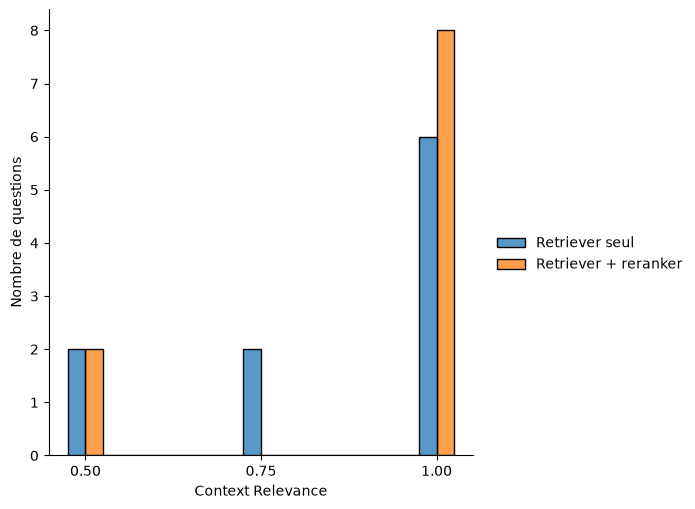

In [266]:
g = sns.displot(
    x=[*scores_retriever_only, *scores_retriever_reranker],
    hue=(
        ["Retriever seul"] * len(scores_retriever_only)
        + ["Retriever + reranker"] * len(scores_retriever_reranker)
    ),
    binwidth=0.05,
    binrange=(0.475, 1.025),
    multiple="dodge",
)

g.set_axis_labels("Context Relevance", "Nombre de questions")

g.ax.set_xticks([0.50, 0.75, 1.00])
g.ax.set_xticklabels(["0.50", "0.75", "1.00"])

max_frequency = int(g.ax.get_ylim()[1])
g.ax.set_yticks(range(0, max_frequency + 1))

plt.show()
